In [1]:
# E-Commerce Book Data Web Scraping using Python

## Project Overview

#This project demonstrates web scraping using Python, Requests, and BeautifulSoup. 
#Book information was collected from the Books to Scrape website and organized 
#into a structured dataset for further analysis.

In [2]:
## Objective

#- Scrape publicly available book data from Books to Scrape.
#- Collect information from all 50 pages of the website.
#- Extract book titles, prices, ratings, availability, product URLs, and categories.
#- Store the collected information in a structured CSV dataset.
#- Create a reusable dataset that can be used for further data analysis.

In [3]:
## Libraries Used

#- **Requests** — to send HTTP requests and retrieve web pages.
#- **BeautifulSoup** — to parse HTML and extract book information.
#- **Pandas** — to organize the scraped data and save it as a CSV file.
#- **urllib.parse** — to create complete product URLs.
#- **ThreadPoolExecutor** — to efficiently retrieve category information from product pages.

In [4]:
## Data Source

#The data was collected from **Books to Scrape**, a website specifically designed for web scraping practice.

#Source: https://books.toscrape.com/

#The website contains 1,000 books distributed across 50 pages.

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin
from concurrent.futures import ThreadPoolExecutor

headers = {
    "User-Agent": "Mozilla/5.0"
}

In [7]:
# Check if we can successfully connect to the website

url = "https://books.toscrape.com/"

response = requests.get(url, headers=headers)
response.encoding = "utf-8"

print("Website status:", response.status_code)

Website status: 200


In [8]:
# Read the webpage and prepare it for extracting book information

soup = BeautifulSoup(response.text, "html.parser")

print("Webpage successfully loaded and parsed.")

Webpage successfully loaded and parsed.


In [9]:
# Find all the book listings available on the current page

books = soup.find_all("article", class_="product_pod")

print("Books found on this page:", len(books))

Books found on this page: 20


In [10]:
# Let's look at the details of the first book

first_book = books[0]

title = first_book.h3.a["title"]
price = first_book.find("p", class_="price_color").get_text(strip=True)
availability = first_book.find(
    "p", class_="instock availability"
).get_text(strip=True)
rating = first_book.find("p", class_="star-rating")["class"][1]

print("Title:", title)
print("Price:", price)
print("Rating:", rating)
print("Availability:", availability)

Title: A Light in the Attic
Price: £51.77
Rating: Three
Availability: In stock


In [11]:
# Get the link to the book's product page

product_url = urljoin(response.url, first_book.h3.a["href"])

print("Product URL:", product_url)

Product URL: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


In [12]:
# Create an empty list to store the book details

books_data = []

In [13]:
# Go through the books on this page and save their details

for book in books:
    title = book.h3.a["title"]
    product_url = urljoin(response.url, book.h3.a["href"])

    price = book.find("p", class_="price_color").get_text(strip=True)
    price = price.replace("Â£", "").replace("£", "")
    price = float(price)

    availability = book.find(
        "p", class_="instock availability"
    ).get_text(strip=True)

    rating = book.find("p", class_="star-rating")["class"][1]

    books_data.append({
        "Title": title,
        "Product_URL": product_url,
        "Price_GBP": price,
        "Rating": rating,
        "Availability": availability
    })

print("Books collected from this page:", len(books_data))

Books collected from this page: 20


In [14]:
# Have a quick look at the data we collected

df = pd.DataFrame(books_data)

df.head()

,Title,Product_URL,Price_GBP,Rating,Availability
0,A Light in the Attic,https://books.toscrape.com/catalogue/a-light-i...,51.77,Three,In stock
1,Tipping the Velvet,https://books.toscrape.com/catalogue/tipping-t...,53.74,One,In stock
2,Soumission,https://books.toscrape.com/catalogue/soumissio...,50.10,One,In stock
3,Sharp Objects,https://books.toscrape.com/catalogue/sharp-obj...,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,https://books.toscrape.com/catalogue/sapiens-a...,54.23,Five,In stock


In [15]:
# Collect book details from all 50 pages

books_data = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url, headers=headers)
    response.encoding = "utf-8"
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        product_url = urljoin(response.url, book.h3.a["href"])

        price = book.find("p", class_="price_color").get_text(strip=True)
        price = price.replace("Â£", "").replace("£", "")
        price = float(price)

        availability = book.find(
            "p", class_="instock availability"
        ).get_text(strip=True)

        rating = book.find("p", class_="star-rating")["class"][1]

        books_data.append({
            "Title": title,
            "Product_URL": product_url,
            "Price_GBP": price,
            "Rating": rating,
            "Availability": availability
        })

print("Total books collected:", len(books_data))

Total books collected: 1000


In [16]:
# Get the category for each book from its product page

def get_category(product_url):
    product_response = requests.get(product_url, headers=headers)
    product_response.encoding = "utf-8"
    product_response.raise_for_status()

    product_soup = BeautifulSoup(product_response.text, "html.parser")

    category = product_soup.select("ul.breadcrumb li a")[-1].get_text(strip=True)

    return category

In [17]:
# Get the category for each book

product_urls = [book["Product_URL"] for book in books_data]

with ThreadPoolExecutor(max_workers=10) as executor:
    categories = list(executor.map(get_category, product_urls))

for book, category in zip(books_data, categories):
    book["Category"] = category

print("Categories added for all books.")

Categories added for all books.


In [18]:
# Put all the scraped information into a table

df = pd.DataFrame(books_data)

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

df.head()

Total rows: 1000
Total columns: 6


,Title,Product_URL,Price_GBP,Rating,Availability,Category
0,A Light in the Attic,https://books.toscrape.com/catalogue/a-light-i...,51.77,Three,In stock,Poetry
1,Tipping the Velvet,https://books.toscrape.com/catalogue/tipping-t...,53.74,One,In stock,Historical Fiction
2,Soumission,https://books.toscrape.com/catalogue/soumissio...,50.10,One,In stock,Fiction
3,Sharp Objects,https://books.toscrape.com/catalogue/sharp-obj...,47.82,Four,In stock,Mystery
4,Sapiens: A Brief History of Humankind,https://books.toscrape.com/catalogue/sapiens-a...,54.23,Five,In stock,History


In [19]:
# Check if any information is missing from the dataset

missing_values = df.isnull().sum()

print(missing_values)

Title           0
Product_URL     0
Price_GBP       0
Rating          0
Availability    0
Category        0
dtype: int64


In [20]:
# Check the type of data stored in each column

print(df.dtypes)

Title               str
Product_URL         str
Price_GBP       float64
Rating              str
Availability        str
Category            str
dtype: object


In [21]:
# Save the complete scraped data as a CSV file

df.to_csv(
    "../data/books_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [22]:
# Check if any books were accidentally collected more than once

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [23]:
# Get a quick summary of the scraped dataset

print(df.describe(include="all"))

                         Title  \
count                     1000   
unique                     999   
top     The Star-Touched Queen   
freq                         2   
mean                       NaN   
std                        NaN   
min                        NaN   
25%                        NaN   
50%                        NaN   
75%                        NaN   
max                        NaN   

                                              Product_URL   Price_GBP Rating  \
count                                                1000  1000.00000   1000   
unique                                               1000         NaN      5   
top     https://books.toscrape.com/catalogue/a-light-i...         NaN    One   
freq                                                    1         NaN    226   
mean                                                  NaN    35.07035    NaN   
std                                                   NaN    14.44669    NaN   
min                            

In [24]:
# See how many books have each rating

rating_counts = df["Rating"].value_counts()

print(rating_counts)

Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [25]:
# See how many books are listed in each category

category_counts = df["Category"].value_counts()

print(category_counts)

Category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Thriller               11
Philosophy             11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Spirituality            6
New Adult               6
Christian Fiction       6
Self Help               5
Biography               5
Sports and Games        5
Health                  4
Politics                3
Contemporary            3
Chr

In [26]:
# Count the books in each category

category_counts = df["Category"].value_counts()

category_counts.head(10)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

In [27]:
# Find the average price of all the books

average_price = df["Price_GBP"].mean()

print(f"Average book price: £{average_price:.2f}")

Average book price: £35.07


In [28]:
# Let's find the cheapest and most expensive books

cheapest = df.loc[df["Price_GBP"].idxmin()]
expensive = df.loc[df["Price_GBP"].idxmax()]

print("Cheapest book:", cheapest["Title"])
print("Price: £", cheapest["Price_GBP"])

print("\nMost expensive book:", expensive["Title"])
print("Price: £", expensive["Price_GBP"])

Cheapest book: An Abundance of Katherines
Price: £ 10.0

Most expensive book: The Perfect Play (Play by Play #1)
Price: £ 59.99


In [29]:
# Let's see how many books are in stock

stock = df["Availability"].value_counts()

print(stock)

Availability
In stock    1000
Name: count, dtype: int64


In [30]:
# Let's see how many different categories we have

number_of_categories = df["Category"].nunique()

print("Number of categories:", number_of_categories)

Number of categories: 50


In [31]:
# Let's find the category with the most books

most_common_category = df["Category"].value_counts().idxmax()
category_total = df["Category"].value_counts().max()

print("Most common category:", most_common_category)
print("Number of books:", category_total)

Most common category: Default
Number of books: 152


In [32]:
# Let's compare the average price of books in each category

average_price_by_category = (
    df.groupby("Category")["Price_GBP"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_category.head(10)

Category
Suspense            58.330000
Novels              54.810000
Politics            53.613333
Health              51.452500
New Adult           46.383333
Christian           42.496667
Sports and Games    41.166000
Self Help           40.620000
Travel              39.794545
Fantasy             39.593958
Name: Price_GBP, dtype: float64

<Axes: title={'center': 'Top 10 Categories by Average Book Price'}, xlabel='Category'>

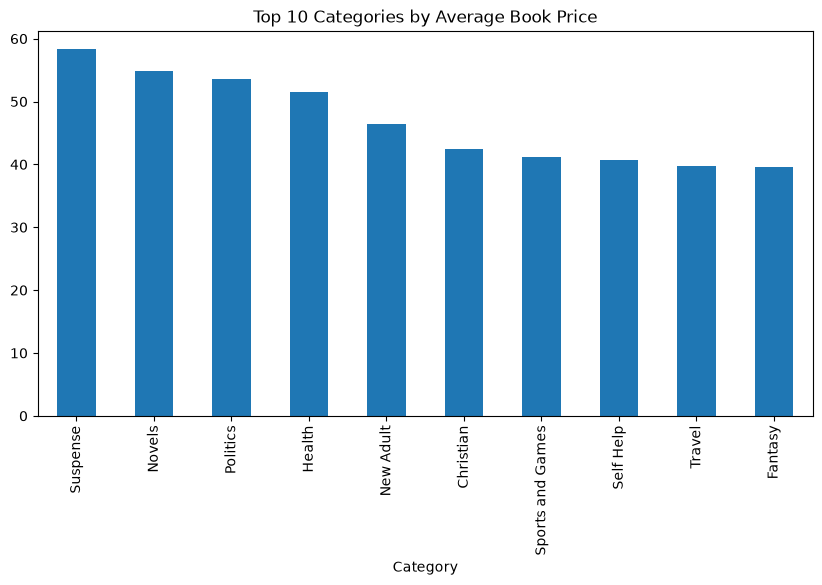

In [34]:
# Let's visualize the average price of the top 10 categories

average_price_by_category.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Categories by Average Book Price"
)

<Axes: title={'center': 'Number of Books by Rating'}, xlabel='Rating'>

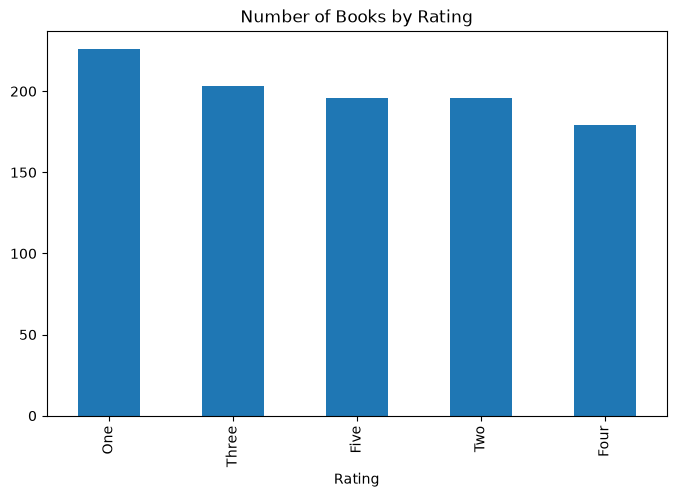

In [35]:
# Let's see how the books are distributed by rating

rating_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Number of Books by Rating"
)

<Axes: title={'center': 'Distribution of Book Prices'}, ylabel='Frequency'>

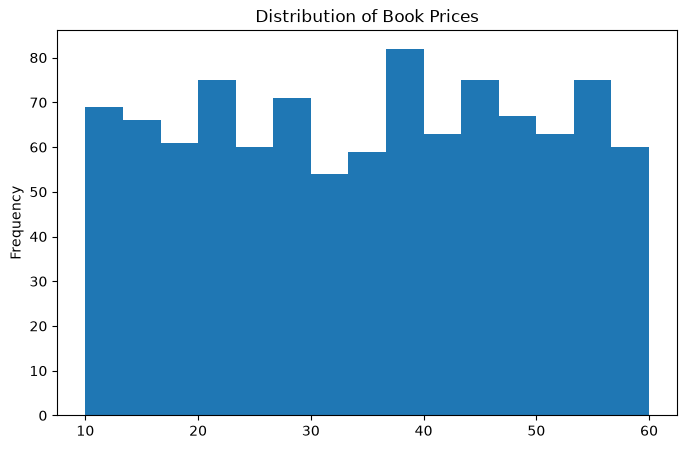

In [36]:
# Let's see how the book prices are distributed

df["Price_GBP"].plot(
    kind="hist",
    bins=15,
    figsize=(8, 5),
    title="Distribution of Book Prices"
)

In [37]:
## Key Findings

#- The dataset contains **1,000 books** collected from 50 pages.
#- The average book price is around **£35.07**.
#- All 1,000 books were listed as **In stock**.
#- The website contains **50 different categories**.
#- The most common rating is **One star**, with 226 books.
#- The most common category is **Default**, with 152 books.
#- Book prices range from **£10.00 to £59.99**.
#- The scraped data contains **no missing values or duplicate rows**.

In [38]:
## Conclusion

#In this project, I used Python to scrape book information from the Books to Scrape website. 
#I collected data from all 50 pages and created a dataset containing 1,000 books.

#The scraped data includes the book title, price, rating, availability, product URL, and category. 
#After collecting the data, I checked for missing values and duplicate records and also created some basic visualizations to understand the dataset.

#This project helped me practice web scraping, data cleaning, data organization, and basic data analysis using Python.